# Encoder Comparison

The previous experiments developed a parallel capability-routing architecture
using a frozen sentence encoder, a trainable routing projection, and a
two-tower decision head.

The best routing configuration reached **97.3% decision accuracy** on the
14-example validation benchmark using `all-MiniLM-L6-v2`.

This notebook keeps the routing architecture, dataset, training procedure, and
evaluation set fixed while changing only the sentence encoder.

The goal is to determine how much routing quality depends on the underlying
semantic representation.

## Controlled Setup

All encoder experiments use:

- 74 training examples
- the same 14-example validation benchmark
- random seed `42`
- frozen sentence encoder
- trainable projection to 128 dimensions
- `TwoTowerDecisionHead` with hidden dimension 128
- binary cross-entropy loss
- AdamW with learning rate `1e-3`
- 100 training epochs
- decision threshold `0.5`

Because only the encoder changes, differences in validation performance can be
attributed more directly to the quality of the frozen representation.

In [1]:
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

from parallel_decider.dataset import (
    ROUTING_LABELS,
    load_routing_dataset,
)
from parallel_decider.projection import RoutingProjection
from parallel_decider.two_tower import TwoTowerDecisionHead

In [2]:
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [3]:
def reset_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
reset_seed()

In [5]:
training_examples = load_routing_dataset(
    "../data/routing_v2.jsonl"
)

benchmark_examples = load_routing_dataset(
    "../data/routing_benchmark.jsonl"
)

benchmark_states = {
    example.state
    for example in benchmark_examples
}

training_examples = [
    example
    for example in training_examples
    if example.state not in benchmark_states
]

print("Training examples:", len(training_examples))
print("Validation examples:", len(benchmark_examples))

Training examples: 74
Validation examples: 14


In [6]:
routing_hypotheses = {
    "needs_filesystem": "This task requires filesystem access.",
    "needs_git": "This task requires Git access.",
    "needs_shell": "This task requires shell execution.",
    "needs_browser": "This task requires browser access.",
    "needs_network": "This task requires network access.",
    "needs_database": "This task requires database access.",
    "needs_email": "This task requires email access.",
    "needs_calendar": "This task requires calendar access.",
}

In [7]:
assert set(routing_hypotheses) == set(ROUTING_LABELS)

for label in ROUTING_LABELS:
    print(f"{label:<20} {routing_hypotheses[label]}")

needs_filesystem     This task requires filesystem access.
needs_git            This task requires Git access.
needs_shell          This task requires shell execution.
needs_browser        This task requires browser access.
needs_network        This task requires network access.
needs_database       This task requires database access.
needs_email          This task requires email access.
needs_calendar       This task requires calendar access.


## Evaluation Metrics

Routing is a multi-label classification problem: every request produces one
binary decision for each available capability.

For every capability we calculate:

- precision,
- recall,
- F1,
- true positives,
- false positives,
- false negatives,
- and true negatives.

We also report overall decision accuracy and macro-averaged precision, recall,
and F1.

Macro metrics give every capability equal weight, which is useful because the
training dataset is not perfectly balanced across capabilities.

In [8]:
def compute_metrics(
    targets: torch.Tensor,
    predictions: torch.Tensor,
) -> pd.DataFrame:
    rows = []

    for index, label in enumerate(ROUTING_LABELS):
        y_true = targets[:, index]
        y_pred = predictions[:, index]

        tp = ((y_pred == 1) & (y_true == 1)).sum().item()
        fp = ((y_pred == 1) & (y_true == 0)).sum().item()
        fn = ((y_pred == 0) & (y_true == 1)).sum().item()
        tn = ((y_pred == 0) & (y_true == 0)).sum().item()

        precision = (
            tp / (tp + fp)
            if tp + fp
            else 0.0
        )

        recall = (
            tp / (tp + fn)
            if tp + fn
            else 0.0
        )

        f1 = (
            2 * precision * recall / (precision + recall)
            if precision + recall
            else 0.0
        )

        rows.append(
            {
                "label": label,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
            }
        )

    return pd.DataFrame(rows)

In [50]:
def prepare_encoder_data(
    model_name: str,
    state_prefix: str = "",
    question_prefix: str = "",
):
    encoder = SentenceTransformer(
        model_name,
        device=device,
    )

    embedding_dim = encoder.get_embedding_dimension()
    
    train_states = [
        state_prefix + example.state
        for example in training_examples
    ]

    benchmark_states_text = [
        state_prefix + example.state
        for example in benchmark_examples
    ]

    question_texts = [
        question_prefix + routing_hypotheses[label]
        for label in ROUTING_LABELS
    ]

    train_embeddings = encoder.encode(
        train_states,
        convert_to_tensor=True,
        show_progress_bar=True,
    ).detach().clone().float()
    
    benchmark_embeddings = encoder.encode(
        benchmark_states_text,
        convert_to_tensor=True,
        show_progress_bar=True,
    ).detach().clone().float()
    
    question_embeddings = encoder.encode(
        question_texts,
        convert_to_tensor=True,
    ).detach().clone().float()

    train_targets = torch.tensor(
        [
            [
                example.labels[label]
                for label in ROUTING_LABELS
            ]
            for example in training_examples
        ],
        dtype=torch.float32,
        device=device,
    )

    benchmark_targets = torch.tensor(
        [
            [
                example.labels[label]
                for label in ROUTING_LABELS
            ]
            for example in benchmark_examples
        ],
        dtype=torch.float32,
        device=device,
    )

    return {
        "encoder": encoder,
        "embedding_dim": embedding_dim,
        "train_embeddings": train_embeddings,
        "benchmark_embeddings": benchmark_embeddings,
        "question_embeddings": question_embeddings,
        "train_targets": train_targets,
        "benchmark_targets": benchmark_targets,
    }

## Training Harness

For each encoder:

1. Sentence embeddings are computed once and kept frozen.
2. A fresh routing projection is initialized.
3. A fresh two-tower decision head is initialized.
4. Only the projection and decision head are trained.
5. The random seed is reset before initialization.
6. The trained model is evaluated on the same validation benchmark.

The projection input dimension is determined automatically from the encoder,
while its output dimension remains fixed at 128.

In [10]:
def train_router(
    prepared_data,
    epochs: int = 100,
    learning_rate: float = 1e-3,
):
    reset_seed()

    embedding_dim = prepared_data["embedding_dim"]

    projection = RoutingProjection(
        input_dim=embedding_dim,
        output_dim=128,
    ).to(device)

    head = TwoTowerDecisionHead(
        embedding_dim=128,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(projection.parameters())
        + list(head.parameters()),
        lr=learning_rate,
    )

    criterion = torch.nn.BCEWithLogitsLoss()

    train_embeddings = prepared_data["train_embeddings"]
    train_targets = prepared_data["train_targets"]
    question_embeddings = prepared_data["question_embeddings"]

    loss_history = []

    progress = tqdm(
        range(epochs),
        desc="Training router",
    )

    for epoch in progress:
        epoch_loss = 0.0

        for state_embedding, targets in zip(
            train_embeddings,
            train_targets,
        ):
            optimizer.zero_grad()

            projected_state = projection(
                state_embedding
            )

            projected_questions = projection(
                question_embeddings
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        average_loss = (
            epoch_loss / len(train_embeddings)
        )

        loss_history.append(
            average_loss
        )

        progress.set_postfix(
            loss=f"{average_loss:.4f}"
        )

    return projection, head, loss_history

In [11]:
def evaluate_router(
    projection,
    head,
    prepared_data,
    threshold: float = 0.5,
    verbose: bool = False,
):
    projection.eval()
    head.eval()

    benchmark_embeddings = prepared_data[
        "benchmark_embeddings"
    ]

    question_embeddings = prepared_data[
        "question_embeddings"
    ]

    targets = prepared_data[
        "benchmark_targets"
    ]

    probability_rows = []

    with torch.no_grad():
        projected_questions = projection(
            question_embeddings
        )

        for index, state_embedding in enumerate(
            benchmark_embeddings
        ):
            projected_state = projection(
                state_embedding
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            probabilities = torch.sigmoid(
                logits
            )

            probability_rows.append(
                probabilities.cpu()
            )

            if verbose:
                example = benchmark_examples[index]

                print(f"\nTest {index + 1}")
                print(example.state)

                predictions = (
                    probabilities >= threshold
                ).int()

                for (
                    label,
                    probability,
                    prediction,
                    target,
                ) in zip(
                    ROUTING_LABELS,
                    probabilities,
                    predictions,
                    targets[index],
                ):
                    print(
                        f"{label:<20} "
                        f"p={probability.item():.3f} "
                        f"pred={int(prediction.item())} "
                        f"target={int(target.item())}"
                    )

    probabilities = torch.stack(
        probability_rows
    )

    predictions = (
        probabilities >= threshold
    ).int()

    targets_cpu = targets.int().cpu()

    accuracy = (
        predictions == targets_cpu
    ).float().mean().item()

    metrics = compute_metrics(
        targets_cpu,
        predictions,
    )

    return {
        "accuracy": accuracy,
        "macro_precision": metrics["precision"].mean(),
        "macro_recall": metrics["recall"].mean(),
        "macro_f1": metrics["f1"].mean(),
        "metrics": metrics,
        "probabilities": probabilities,
        "predictions": predictions,
        "targets": targets_cpu,
    }

In [12]:
def run_encoder_experiment(
    name: str,
    model_name: str,
    state_prefix: str = "",
    question_prefix: str = "",
    verbose: bool = False,
):
    print("=" * 70)
    print(name)
    print(model_name)
    print("=" * 70)

    prepared = prepare_encoder_data(
        model_name=model_name,
        state_prefix=state_prefix,
        question_prefix=question_prefix,
    )

    print(
        "Embedding dimension:",
        prepared["embedding_dim"],
    )

    projection, head, loss_history = train_router(
        prepared
    )

    result = evaluate_router(
        projection,
        head,
        prepared,
        verbose=verbose,
    )

    print()
    print(
        f"Accuracy:        "
        f"{result['accuracy']:.3%}"
    )

    print(
        f"Macro precision: "
        f"{result['macro_precision']:.3f}"
    )

    print(
        f"Macro recall:    "
        f"{result['macro_recall']:.3f}"
    )

    print(
        f"Macro F1:        "
        f"{result['macro_f1']:.3f}"
    )

    return {
        "name": name,
        "model_name": model_name,
        "prepared": prepared,
        "projection": projection,
        "head": head,
        "loss_history": loss_history,
        "result": result,
    }

## Experiment 1 — MiniLM Baseline

The first experiment reproduces the encoder used throughout the previous
routing experiments:

`sentence-transformers/all-MiniLM-L6-v2`

MiniLM produces 384-dimensional sentence embeddings.

The purpose of this run is not to discover a new result, but to verify that the
new encoder-comparison harness reproduces the V5 baseline before alternative
encoders are introduced.

In [13]:
minilm_experiment = run_encoder_experiment(
    name="MiniLM L6 v2",
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    verbose=True,
)

MiniLM L6 v2
sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/4229970689.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 384


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.298 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [14]:
minilm_experiment["result"]["metrics"][
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.0,0.833,0.909,5,0,1
1,needs_git,1.0,1.000,1.000,1,0,0
2,needs_shell,1.0,1.000,1.000,2,0,0
3,needs_browser,1.0,1.000,1.000,2,0,0
4,needs_network,1.0,1.000,1.000,6,0,0
5,needs_database,1.0,1.000,1.000,4,0,0
6,needs_email,1.0,1.000,1.000,2,0,0
7,needs_calendar,1.0,1.000,1.000,3,0,0


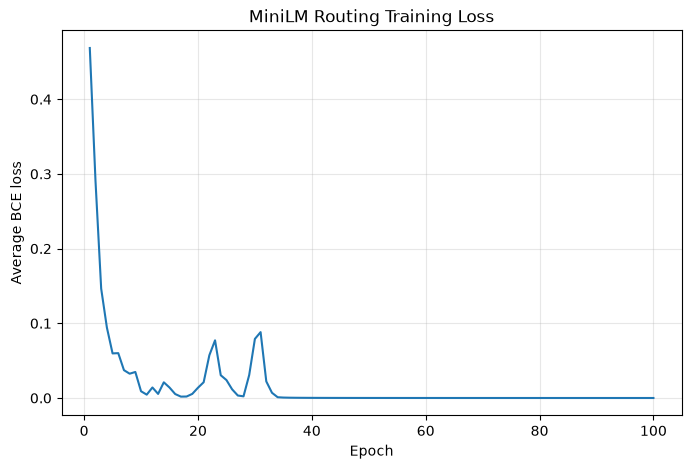

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(minilm_experiment["loss_history"]) + 1,
    ),
    minilm_experiment["loss_history"],
)

plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("MiniLM Routing Training Loss")
plt.grid(True, alpha=0.3)

plt.show()

## Experiment 2 — BGE Small

The second experiment replaces MiniLM with `BAAI/bge-small-en-v1.5`.

BGE Small also produces 384-dimensional embeddings, making it a particularly
clean comparison with MiniLM.

The routing projection, decision head, training examples, validation examples,
random seed, optimizer, number of epochs, and decision threshold remain
unchanged.

In [16]:
bge_small_experiment = run_encoder_experiment(
    name="BGE Small EN v1.5",
    model_name="BAAI/bge-small-en-v1.5",
    verbose=True,
)

BGE Small EN v1.5
BAAI/bge-small-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/4229970689.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 384


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.009 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

## Experiment 3 — E5 Small

Earlier experiments found that raw E5 cosine similarity was not sufficient for
capability routing.

This experiment tests a different question: whether E5 embeddings become useful
when combined with the learned routing projection and decision head.

E5 uses task prefixes during embedding. States are treated as queries and
routing hypotheses as passages.

In [17]:
e5_small_experiment = run_encoder_experiment(
    name="E5 Small v2",
    model_name="intfloat/e5-small-v2",
    state_prefix="query: ",
    question_prefix="passage: ",
    verbose=True,
)

E5 Small v2
intfloat/e5-small-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/4229970689.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 384


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.164 pred=0 target=0
needs_shell          p=0.773 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [18]:
experiments = [
    minilm_experiment,
    bge_small_experiment,
    e5_small_experiment,
]

In [19]:
comparison_rows = []

for experiment in experiments:
    result = experiment["result"]

    comparison_rows.append(
        {
            "encoder": experiment["name"],
            "embedding_dim": experiment[
                "prepared"
            ]["embedding_dim"],
            "accuracy": result["accuracy"],
            "macro_precision": result[
                "macro_precision"
            ],
            "macro_recall": result[
                "macro_recall"
            ],
            "macro_f1": result[
                "macro_f1"
            ],
        }
    )

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_df

,encoder,embedding_dim,accuracy,macro_precision,macro_recall,macro_f1
0,MiniLM L6 v2,384,0.991071,1.000000,0.979167,0.988636
1,BGE Small EN v1.5,384,0.991071,1.000000,0.968750,0.982143
2,E5 Small v2,384,0.982143,0.982143,0.937500,0.948718


In [20]:
display_df = comparison_df.copy()

for column in [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
]:
    display_df[column] = (
        display_df[column] * 100
    ).round(2)

display_df

,encoder,embedding_dim,accuracy,macro_precision,macro_recall,macro_f1
0,MiniLM L6 v2,384,99.11,100.00,97.92,98.86
1,BGE Small EN v1.5,384,99.11,100.00,96.88,98.21
2,E5 Small v2,384,98.21,98.21,93.75,94.87


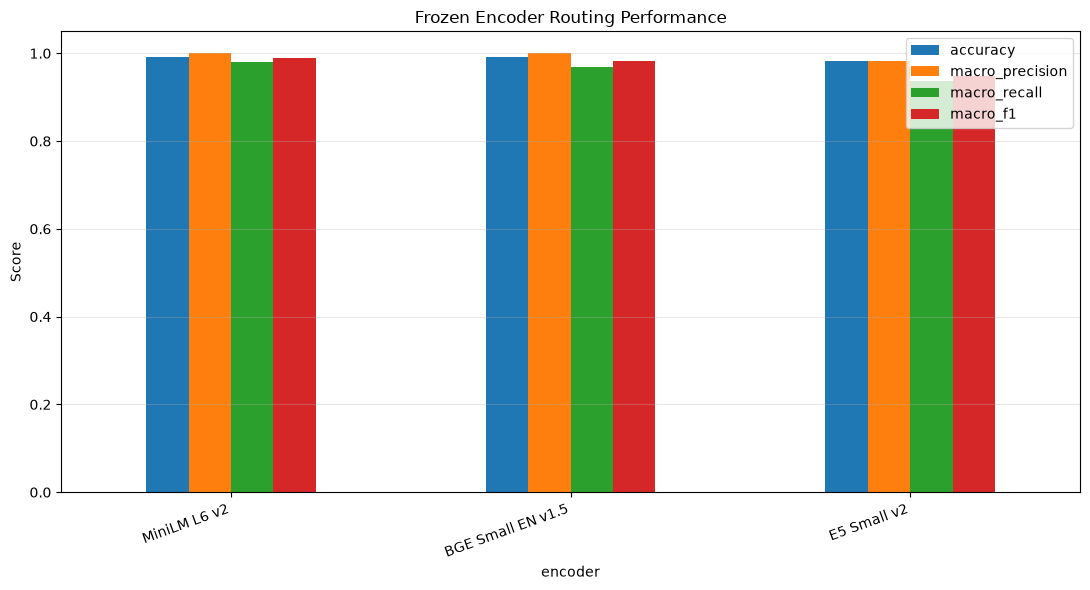

In [21]:
plot_df = comparison_df.set_index(
    "encoder"
)[
    [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.05)
ax.set_title(
    "Frozen Encoder Routing Performance"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.grid(
    axis="y",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

## Initial Encoder Comparison

These experiments isolate the frozen sentence encoder while keeping the routing
architecture and training procedure constant.

This allows us to distinguish improvements caused by better generic semantic
representations from improvements caused by routing-specific supervision.

The comparison should not be interpreted as a general ranking of the embedding
models. It measures their usefulness specifically as frozen representations for
this capability-routing architecture and dataset.

Additional experiments will include larger encoders and, later, partial encoder
fine-tuning.

## Small-Encoder Results

All three frozen encoders perform strongly when combined with the learned
routing projection and decision head.

| Encoder | Accuracy | Macro Precision | Macro Recall | Macro F1 |
| --- | ---: | ---: | ---: | ---: |
| MiniLM L6 v2 | **99.11%** | **1.000** | **0.979** | **0.989** |
| BGE Small EN v1.5 | **99.11%** | **1.000** | 0.969 | 0.982 |
| E5 Small v2 | 98.21% | 0.982 | 0.938 | 0.949 |

MiniLM and BGE each make only one incorrect decision across 112 validation
decisions, while E5 makes two.

The remaining errors differ between encoders:

- MiniLM misses filesystem access for the application-log request.
- BGE detects the filesystem requirement but narrowly misses database access
  for the same request.
- E5 handles that mixed filesystem/database request correctly, but misses one
  email request and introduces one network false positive.

This suggests that the learned routing projection is able to extract useful
capability information from several generic embedding spaces, while the
underlying encoder still affects which semantic distinctions generalize best.

The E5 result is particularly notable because raw E5 cosine similarity performed
poorly in an earlier experiment. With a trainable routing projection, the same
encoder reaches strong routing performance, supporting the hypothesis that
generic embedding geometry does not need to align directly with capability
boundaries.

### Comparison Scope

The absolute MiniLM score differs slightly from the earlier V5 notebook because
this notebook uses a new standardized comparison harness, including batched
embedding preparation and consistent seed reset immediately before each model
initialization.

Results within this notebook are directly comparable because every encoder uses
the same preparation, training, and evaluation pipeline.

In [22]:
import gc

small_encoder_results = comparison_df.copy()

del minilm_experiment
del bge_small_experiment
del e5_small_experiment

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 0.35 GB


## Experiment 4 — MPNet Base

The next experiment moves from 384-dimensional small encoders to the larger
`all-mpnet-base-v2` encoder.

MPNet produces 768-dimensional sentence embeddings.

The routing projection automatically adapts its input dimension from 384 to
768 while continuing to project into the same 128-dimensional routing space.

Everything else remains fixed:

- training and validation data,
- random seed,
- projection output dimension,
- decision head,
- optimizer,
- learning rate,
- number of epochs,
- and classification threshold.

This tests whether a larger generic semantic representation improves capability
routing when the routing-specific architecture remains unchanged.

In [23]:
mpnet_experiment = run_encoder_experiment(
    name="MPNet Base v2",
    model_name="sentence-transformers/all-mpnet-base-v2",
    verbose=True,
)

MPNet Base v2
sentence-transformers/all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 768


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.001 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.270 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [24]:
mpnet_experiment["result"]["metrics"][
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.0,0.833,0.909,5,0,1
1,needs_git,1.0,1.000,1.000,1,0,0
2,needs_shell,1.0,1.000,1.000,2,0,0
3,needs_browser,1.0,1.000,1.000,2,0,0
4,needs_network,1.0,1.000,1.000,6,0,0
5,needs_database,1.0,1.000,1.000,4,0,0
6,needs_email,1.0,1.000,1.000,2,0,0
7,needs_calendar,1.0,0.667,0.800,2,0,1


In [25]:
result = mpnet_experiment["result"]

mpnet_row = pd.DataFrame(
    [
        {
            "encoder": mpnet_experiment["name"],
            "embedding_dim": mpnet_experiment[
                "prepared"
            ]["embedding_dim"],
            "accuracy": result["accuracy"],
            "macro_precision": result[
                "macro_precision"
            ],
            "macro_recall": result[
                "macro_recall"
            ],
            "macro_f1": result[
                "macro_f1"
            ],
        }
    ]
)

comparison_df = pd.concat(
    [
        small_encoder_results,
        mpnet_row,
    ],
    ignore_index=True,
)

comparison_df

,encoder,embedding_dim,accuracy,macro_precision,macro_recall,macro_f1
0,MiniLM L6 v2,384,0.991071,1.000000,0.979167,0.988636
1,BGE Small EN v1.5,384,0.991071,1.000000,0.968750,0.982143
2,E5 Small v2,384,0.982143,0.982143,0.937500,0.948718
3,MPNet Base v2,768,0.982143,1.000000,0.937500,0.963636


### MPNet Observation

Moving from a 384-dimensional small encoder to the 768-dimensional
`all-mpnet-base-v2` representation does not improve overall routing performance.

MPNet reaches **98.2% accuracy** and **0.964 macro F1**, with two false
negatives.

Its error profile differs from the smaller encoders. In particular, MPNet
correctly identifies both filesystem and database access in the mixed
application-log request, but misses calendar access in a combined
email/calendar request and filesystem access in a web-to-local-file request.

This provides additional evidence that larger embedding dimensionality alone
does not guarantee better capability routing.

In [26]:
mpnet_result_row = comparison_df.iloc[[-1]].copy()

del mpnet_experiment

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 0.35 GB


## Experiment 5 — BGE Base

This experiment evaluates `BAAI/bge-base-en-v1.5`, a larger member of the BGE
embedding family.

Like MPNet Base, BGE Base produces 768-dimensional embeddings.

This comparison therefore helps separate the effect of embedding dimensionality
from the effect of the underlying encoder and training objective.

The routing architecture and experimental setup remain unchanged.

In [27]:
bge_base_experiment = run_encoder_experiment(
    name="BGE Base EN v1.5",
    model_name="BAAI/bge-base-en-v1.5",
    verbose=True,
)

BGE Base EN v1.5
BAAI/bge-base-en-v1.5


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 768


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.256 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [28]:
bge_base_experiment["result"]["metrics"][
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.0,1.0,1.0,6,0,0
1,needs_git,1.0,1.0,1.0,1,0,0
2,needs_shell,1.0,1.0,1.0,2,0,0
3,needs_browser,1.0,1.0,1.0,2,0,0
4,needs_network,1.0,1.0,1.0,6,0,0
5,needs_database,1.0,1.0,1.0,4,0,0
6,needs_email,1.0,1.0,1.0,2,0,0
7,needs_calendar,1.0,1.0,1.0,3,0,0


In [29]:
result = bge_base_experiment["result"]

bge_base_row = pd.DataFrame(
    [
        {
            "encoder": bge_base_experiment["name"],
            "embedding_dim": bge_base_experiment[
                "prepared"
            ]["embedding_dim"],
            "accuracy": result["accuracy"],
            "macro_precision": result[
                "macro_precision"
            ],
            "macro_recall": result[
                "macro_recall"
            ],
            "macro_f1": result[
                "macro_f1"
            ],
        }
    ]
)

comparison_df = pd.concat(
    [
        comparison_df,
        bge_base_row,
    ],
    ignore_index=True,
)

comparison_df

,encoder,embedding_dim,accuracy,macro_precision,macro_recall,macro_f1
0,MiniLM L6 v2,384,0.991071,1.000000,0.979167,0.988636
1,BGE Small EN v1.5,384,0.991071,1.000000,0.968750,0.982143
2,E5 Small v2,384,0.982143,0.982143,0.937500,0.948718
3,MPNet Base v2,768,0.982143,1.000000,0.937500,0.963636
4,BGE Base EN v1.5,768,1.000000,1.000000,1.000000,1.000000


### BGE Base Observation

`BAAI/bge-base-en-v1.5` achieves perfect performance on the current fixed
validation benchmark:

- **100.0% decision accuracy**
- **1.000 macro precision**
- **1.000 macro recall**
- **1.000 macro F1**

All 112 capability decisions across the 14 validation requests are classified
correctly.

This is the strongest result in the encoder comparison so far.

The result also shows that increasing representation size alone is not enough:
MPNet Base uses the same 768-dimensional embedding size but performs worse than
both BGE Base and the smaller MiniLM encoder.

This suggests that the semantic structure of the pretrained embedding space is
more important for this routing task than embedding dimensionality by itself.

Because the validation set is small and has been used throughout model
development, this result should not be interpreted as evidence of perfect
generalization. A separate untouched test set will be required for the final
evaluation.

In [30]:
bge_base_result_row = comparison_df.iloc[[-1]].copy()

del bge_base_experiment

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(
    f"GPU memory allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

GPU memory allocated: 0.35 GB


## Experiment 6 — GTE ModernBERT Base

This experiment evaluates `Alibaba-NLP/gte-modernbert-base`.

Like BGE Base and MPNet Base, GTE ModernBERT produces 768-dimensional
embeddings, allowing the same `768 → 128` routing projection to be used.

Unlike the previous encoders, GTE ModernBERT supports substantially longer
input sequences. This may become important when the routing state eventually
contains conversation history, repository context, tool state, or other
agent-level information.

For the current experiment, however, the request texts remain unchanged.
Therefore this experiment tests representation quality rather than long-context
behavior.

All routing architecture and training parameters remain fixed.

In [33]:
gte_modernbert_experiment = run_encoder_experiment(
    name="GTE ModernBERT Base",
    model_name="Alibaba-NLP/gte-modernbert-base",
    verbose=True,
)

GTE ModernBERT Base
Alibaba-NLP/gte-modernbert-base


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/624449527.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 768


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Test 1
Write a Python example that connects to a PostgreSQL database, but do not run it.
needs_filesystem     p=0.000 pred=0 target=0
needs_git            p=0.000 pred=0 target=0
needs_shell          p=0.000 pred=0 target=0
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.011 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 2
Inspect the project, locate the broken test, and execute only that test.
needs_filesystem     p=1.000 pred=1 target=1
needs_git            p=0.000 pred=0 target=0
needs_shell          p=1.000 pred=1 target=1
needs_browser        p=0.000 pred=0 target=0
needs_network        p=0.000 pred=0 target=0
needs_database       p=0.000 pred=0 target=0
needs_email          p=0.000 pred=0 target=0
needs_calendar       p=0.000 pred=0 target=0

Test 3
Move my meeting with Alice to next Monday afternoon.
needs_filesystem     p=0.000 pred=0 target=0
nee

In [34]:
gte_modernbert_experiment["result"]["metrics"][
    [
        "label",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
    ]
].round(3)

,label,precision,recall,f1,tp,fp,fn
0,needs_filesystem,1.0,0.833,0.909,5,0,1
1,needs_git,1.0,1.000,1.000,1,0,0
2,needs_shell,1.0,1.000,1.000,2,0,0
3,needs_browser,1.0,0.500,0.667,1,0,1
4,needs_network,1.0,1.000,1.000,6,0,0
5,needs_database,1.0,1.000,1.000,4,0,0
6,needs_email,1.0,1.000,1.000,2,0,0
7,needs_calendar,1.0,1.000,1.000,3,0,0


In [35]:
result = gte_modernbert_experiment["result"]

gte_modernbert_row = pd.DataFrame(
    [
        {
            "encoder": gte_modernbert_experiment["name"],
            "embedding_dim": gte_modernbert_experiment[
                "prepared"
            ]["embedding_dim"],
            "accuracy": result["accuracy"],
            "macro_precision": result[
                "macro_precision"
            ],
            "macro_recall": result[
                "macro_recall"
            ],
            "macro_f1": result[
                "macro_f1"
            ],
        }
    ]
)

comparison_df = pd.concat(
    [
        comparison_df,
        gte_modernbert_row,
    ],
    ignore_index=True,
)

comparison_df

,encoder,embedding_dim,accuracy,macro_precision,macro_recall,macro_f1
0,MiniLM L6 v2,384,0.991071,1.000000,0.979167,0.988636
1,BGE Small EN v1.5,384,0.991071,1.000000,0.968750,0.982143
2,E5 Small v2,384,0.982143,0.982143,0.937500,0.948718
3,MPNet Base v2,768,0.982143,1.000000,0.937500,0.963636
4,BGE Base EN v1.5,768,1.000000,1.000000,1.000000,1.000000
5,GTE ModernBERT Base,768,0.982143,1.000000,0.916667,0.946970


## Encoder Quality Summary

Six frozen sentence encoders were evaluated using the same routing dataset,
projection architecture, decision head, random seed, training procedure, and
validation benchmark.

| Encoder | Embedding Dim | Accuracy | Macro Precision | Macro Recall | Macro F1 |
| --- | ---: | ---: | ---: | ---: | ---: |
| BGE Base EN v1.5 | 768 | **100.00%** | **1.000** | **1.000** | **1.000** |
| MiniLM L6 v2 | 384 | 99.11% | 1.000 | 0.979 | 0.989 |
| BGE Small EN v1.5 | 384 | 99.11% | 1.000 | 0.969 | 0.982 |
| MPNet Base v2 | 768 | 98.21% | 1.000 | 0.938 | 0.964 |
| E5 Small v2 | 384 | 98.21% | 0.982 | 0.938 | 0.949 |
| GTE ModernBERT Base | 768 | 98.21% | 1.000 | 0.917 | 0.947 |

BGE Base is the only encoder to classify all 112 validation decisions
correctly.

However, encoder size and embedding dimensionality do not correlate directly
with routing quality. MPNet and GTE ModernBERT both use 768-dimensional
representations but perform below the smaller MiniLM encoder.

The comparison therefore suggests that the structure of the pretrained
representation is more important for this routing task than embedding
dimensionality alone.

Because the validation set is small and has influenced earlier dataset
development, these numbers should be treated as validation results rather than
final generalization estimates. A separate untouched test set will be used for
the final evaluation.

## Encoder Latency

Routing quality is only one part of the design tradeoff.

The encoder runs once for every new agent state, while the routing projection
and decision head are comparatively small.

The next experiment measures single-state encoding latency for each encoder on
the same GPU.

Routing hypotheses are static and can be precomputed, so the production-critical
path is primarily:

`state → encoder → projection → parallel decisions`

In [36]:
import time
import gc

In [37]:
def benchmark_encoder(
    model_name: str,
    texts: list[str],
    state_prefix: str = "",
    warmup_runs: int = 10,
    measured_runs: int = 50,
):
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    encoder = SentenceTransformer(
        model_name,
        device=device,
    )

    inputs = [
        state_prefix + text
        for text in texts
    ]

    # Warm up GPU kernels.
    for _ in range(warmup_runs):
        encoder.encode(
            inputs,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    timings = []

    for _ in range(measured_runs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        encoder.encode(
            inputs,
            convert_to_tensor=True,
            show_progress_bar=False,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        timings.append(
            (time.perf_counter() - start) * 1000
        )

    result = {
        "mean_ms": np.mean(timings),
        "median_ms": np.median(timings),
        "std_ms": np.std(timings),
    }

    del encoder

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [38]:
latency_texts = [
    "Inspect the repository, identify the commit that introduced "
    "the authentication regression, run the relevant tests, "
    "and explain what caused the problem."
]

In [39]:
encoder_configs = [
    {
        "name": "MiniLM L6 v2",
        "model_name": "sentence-transformers/all-MiniLM-L6-v2",
        "state_prefix": "",
    },
    {
        "name": "BGE Small EN v1.5",
        "model_name": "BAAI/bge-small-en-v1.5",
        "state_prefix": "",
    },
    {
        "name": "E5 Small v2",
        "model_name": "intfloat/e5-small-v2",
        "state_prefix": "query: ",
    },
    {
        "name": "MPNet Base v2",
        "model_name": "sentence-transformers/all-mpnet-base-v2",
        "state_prefix": "",
    },
    {
        "name": "BGE Base EN v1.5",
        "model_name": "BAAI/bge-base-en-v1.5",
        "state_prefix": "",
    },
    {
        "name": "GTE ModernBERT Base",
        "model_name": "Alibaba-NLP/gte-modernbert-base",
        "state_prefix": "",
    },
]

In [40]:
latency_rows = []

for config in encoder_configs:
    print("Benchmarking:", config["name"])

    timing = benchmark_encoder(
        model_name=config["model_name"],
        texts=latency_texts,
        state_prefix=config["state_prefix"],
    )

    latency_rows.append(
        {
            "encoder": config["name"],
            **timing,
        }
    )

latency_df = pd.DataFrame(latency_rows)

latency_df.round(2)

Benchmarking: MiniLM L6 v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Benchmarking: BGE Small EN v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Benchmarking: E5 Small v2


...

Benchmarking: BGE Base EN v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Benchmarking: GTE ModernBERT Base


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

,encoder,mean_ms,median_ms,std_ms
0,MiniLM L6 v2,4.51,4.40,0.30
1,BGE Small EN v1.5,7.67,7.61,0.30
2,E5 Small v2,7.99,7.95,0.43
3,MPNet Base v2,8.79,8.69,0.64
4,BGE Base EN v1.5,7.95,7.76,0.42
5,GTE ModernBERT Base,14.72,14.62,0.38


## Encoder Latency Results

Single-state encoding latency was measured on the same GPU using repeated
warm runs and explicit CUDA synchronization.

| Encoder | Median Latency | Relative to MiniLM |
| --- | ---: | ---: |
| MiniLM L6 v2 | **4.40 ms** | **1.00×** |
| BGE Small EN v1.5 | 7.61 ms | 1.73× |
| BGE Base EN v1.5 | 7.76 ms | 1.76× |
| E5 Small v2 | 7.95 ms | 1.81× |
| MPNet Base v2 | 8.69 ms | 1.98× |
| GTE ModernBERT Base | 14.62 ms | 3.32× |

MiniLM provides the lowest encoding latency, while BGE Base provides the
strongest validation quality.

BGE Base is particularly interesting because its latency is only about
3.4 milliseconds higher than MiniLM despite producing a 768-dimensional
representation instead of 384 dimensions.

GTE ModernBERT is substantially slower for the short requests used in this
experiment and does not improve routing quality. Its longer context window may
still become useful when routing decisions operate over substantially larger
agent states.

For the current workload, MiniLM and BGE Base represent the most interesting
quality/latency trade-off.

In [41]:
latency_summary = latency_df[
    [
        "encoder",
        "mean_ms",
        "median_ms",
        "std_ms",
    ]
]

quality_latency_df = comparison_df.merge(
    latency_summary,
    on="encoder",
)

quality_latency_df["relative_latency"] = (
    quality_latency_df["median_ms"]
    / quality_latency_df.loc[
        quality_latency_df["encoder"] == "MiniLM L6 v2",
        "median_ms",
    ].iloc[0]
)

quality_latency_df[
    [
        "encoder",
        "embedding_dim",
        "accuracy",
        "macro_f1",
        "median_ms",
        "relative_latency",
    ]
].round(3)

,encoder,embedding_dim,accuracy,macro_f1,median_ms,relative_latency
0,MiniLM L6 v2,384,0.991,0.989,4.404,1.000
1,BGE Small EN v1.5,384,0.991,0.982,7.612,1.728
2,E5 Small v2,384,0.982,0.949,7.951,1.805
3,MPNet Base v2,768,0.982,0.964,8.691,1.973
4,BGE Base EN v1.5,768,1.000,1.000,7.765,1.763
5,GTE ModernBERT Base,768,0.982,0.947,14.619,3.319


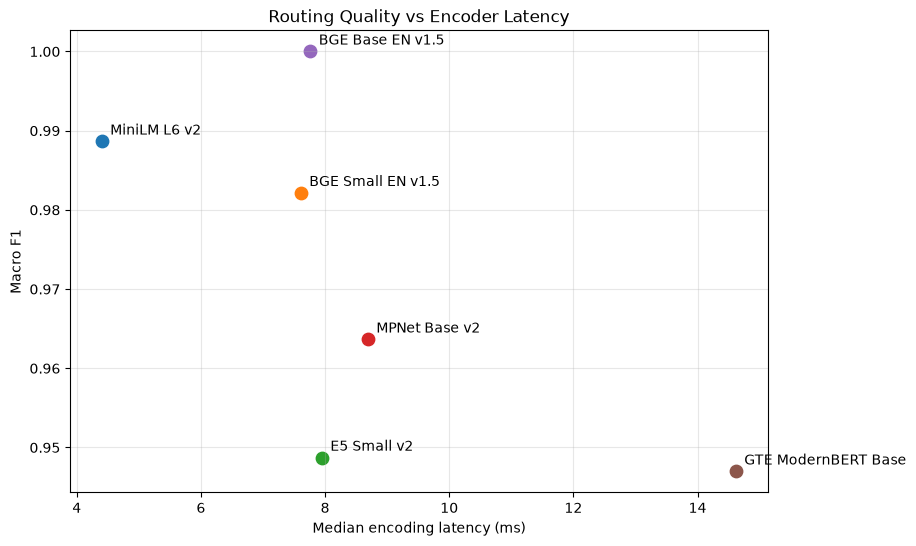

In [42]:
plt.figure(figsize=(9, 6))

for _, row in quality_latency_df.iterrows():
    plt.scatter(
        row["median_ms"],
        row["macro_f1"],
        s=80,
    )

    plt.annotate(
        row["encoder"],
        (
            row["median_ms"],
            row["macro_f1"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
    )

plt.xlabel("Median encoding latency (ms)")
plt.ylabel("Macro F1")
plt.title("Routing Quality vs Encoder Latency")
plt.grid(True, alpha=0.3)

plt.show()

## End-to-End Routing Latency

Encoder latency measures only the cost of producing the shared state
representation.

The actual routing pipeline also includes:

`state → encoder → routing projection → parallel capability scoring`

Because the state is encoded only once and all capability decisions are scored
from the shared representation, the additional routing cost should be small
relative to the encoder itself.

This experiment measures the complete latency for producing all eight capability
probabilities.

Only the two most interesting encoder configurations are benchmarked:

- MiniLM — lowest encoder latency
- BGE Base — highest validation quality

In [43]:
def benchmark_full_router(
    encoder,
    projection,
    head,
    question_embeddings,
    text: str,
    state_prefix: str = "",
    warmup_runs: int = 20,
    measured_runs: int = 100,
):
    projection.eval()
    head.eval()

    projected_questions = projection(
        question_embeddings.float()
    )

    timings = []

    with torch.no_grad():
        # Warm-up
        for _ in range(warmup_runs):
            state_embedding = encoder.encode(
                state_prefix + text,
                convert_to_tensor=True,
                show_progress_bar=False,
            ).detach().clone().float()

            projected_state = projection(
                state_embedding
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            torch.sigmoid(logits)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        # Measured runs
        for _ in range(measured_runs):
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            start = time.perf_counter()

            state_embedding = encoder.encode(
                state_prefix + text,
                convert_to_tensor=True,
                show_progress_bar=False,
            ).detach().clone().float()

            projected_state = projection(
                state_embedding
            )

            logits = head(
                state_embedding=projected_state,
                question_embeddings=projected_questions,
            )

            probabilities = torch.sigmoid(
                logits
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            elapsed_ms = (
                time.perf_counter() - start
            ) * 1000

            timings.append(elapsed_ms)

    return {
        "mean_ms": np.mean(timings),
        "median_ms": np.median(timings),
        "std_ms": np.std(timings),
    }

In [44]:
minilm_final = run_encoder_experiment(
    name="MiniLM L6 v2",
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    verbose=False,
)

MiniLM L6 v2
sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/624449527.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 384


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Accuracy:        99.107%
Macro precision: 1.000
Macro recall:    0.979
Macro F1:        0.989


In [45]:
routing_text = (
    "Inspect the repository, identify the commit that introduced "
    "the authentication regression, run the relevant tests, "
    "and explain what caused the problem."
)

minilm_latency = benchmark_full_router(
    encoder=minilm_final["prepared"]["encoder"],
    projection=minilm_final["projection"],
    head=minilm_final["head"],
    question_embeddings=minilm_final[
        "prepared"
    ]["question_embeddings"],
    text=routing_text,
)

In [46]:
minilm_full_result = {
    "encoder": "MiniLM L6 v2",
    **minilm_latency,
}

del minilm_final

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [47]:
bge_base_final = run_encoder_experiment(
    name="BGE Base EN v1.5",
    model_name="BAAI/bge-base-en-v1.5",
    verbose=False,
)

BGE Base EN v1.5
BAAI/bge-base-en-v1.5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_2756830/624449527.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_dim = encoder.get_sentence_embedding_dimension()


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding dimension: 768


Training router:   0%|          | 0/100 [00:00<?, ?it/s]


Accuracy:        100.000%
Macro precision: 1.000
Macro recall:    1.000
Macro F1:        1.000


In [48]:
bge_base_latency = benchmark_full_router(
    encoder=bge_base_final["prepared"]["encoder"],
    projection=bge_base_final["projection"],
    head=bge_base_final["head"],
    question_embeddings=bge_base_final[
        "prepared"
    ]["question_embeddings"],
    text=routing_text,
)

In [49]:
bge_base_full_result = {
    "encoder": "BGE Base EN v1.5",
    **bge_base_latency,
}

full_router_latency_df = pd.DataFrame(
    [
        minilm_full_result,
        bge_base_full_result,
    ]
)

full_router_latency_df.round(3)

,encoder,mean_ms,median_ms,std_ms
0,MiniLM L6 v2,5.220,5.177,0.29
1,BGE Base EN v1.5,8.442,8.394,0.39


## End-to-End Routing Results

The final benchmark measures the complete routing path:

`state → encoder → routing projection → 8 parallel capability decisions`

| Encoder | Validation Accuracy | Macro F1 | Encoder Median | Full Router Median | Routing Overhead |
| --- | ---: | ---: | ---: | ---: | ---: |
| MiniLM L6 v2 | 99.11% | 0.989 | 4.404 ms | 5.177 ms | 0.773 ms |
| BGE Base EN v1.5 | **100.00%** | **1.000** | 7.765 ms | 8.394 ms | **0.629 ms** |

The routing-specific layers add less than one millisecond to either encoder.

This confirms an important architectural property of the two-tower design:
once the shared state representation has been computed, multiple capability
decisions can be produced with relatively little additional cost.

For MiniLM, the routing layers add approximately 0.77 ms.

For BGE Base, they add approximately 0.63 ms.

The majority of end-to-end latency is therefore spent encoding the state rather
than evaluating the individual capability decisions.

BGE Base currently provides the strongest quality result, producing all eight
capability decisions in approximately **8.4 ms median end-to-end latency** on
the test GPU.

MiniLM remains an attractive lower-latency alternative at approximately
**5.2 ms**, with only one incorrect decision on the current validation
benchmark.

## Conclusion

The encoder comparison shows that the routing architecture is not tied to a
single embedding model.

Six frozen encoders were evaluated under the same routing architecture and
training procedure. Performance varied by encoder, but several produced strong
results after the trainable routing projection was applied.

BGE Base achieved the strongest validation result:

- 100% decision accuracy
- 1.000 macro F1
- 7.8 ms median state-encoding latency
- 8.4 ms median end-to-end routing latency

MiniLM provided the strongest latency/quality trade-off:

- 99.1% decision accuracy
- 0.989 macro F1
- 4.4 ms median state-encoding latency
- 5.2 ms median end-to-end routing latency

The routing projection and decision head add less than one millisecond of
latency, indicating that the main computational cost is the shared state
encoder.

These results support the central design idea of the project: encode the agent
state once, then evaluate many independent typed decisions against that shared
representation in parallel.

The current validation benchmark is small and has influenced earlier model
development, so these results should be treated as development metrics rather
than final generalization estimates.

The next stage should evaluate the selected architecture on a larger,
previously unseen test set.